### Quantum Kernel Training com Qiskit

Este notebook tem como objetivo aplicar uma etapa experimental de `Quantum Machine Learning` seguindo boas práticas inspiradas no fluxo oficial da IBM Quantum para `Quantum Kernel Training`.

Nos notebooks anteriores, o Autoencoder reduziu as 15 variáveis originais do dataset para 4 variáveis latentes. Neste notebook, essas variáveis serão usadas como entrada para circuitos quânticos.

A proposta não é treinar um classificador quântico completo no dataset inteiro, pois isso teria alto custo computacional. Em vez disso, vamos demonstrar como calcular uma entrada da matriz de kernel entre duas amostras do espaço latente.

Esse processo segue a lógica apresentada pela IBM Quantum:

- mapear os dados clássicos para um circuito quântico;
- otimizar o circuito para execução;
- executar usando primitivas do Qiskit;
- pós-processar o resultado para obter uma medida de similaridade.

Essa abordagem é mais adequada para o escopo do projeto, pois mostra como os dados gerados pelo Autoencoder podem ser conectados a um fluxo real de computação quântica com Qiskit.

In [31]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
from qiskit.circuit.library import zz_feature_map, unitary_overlap
from qiskit.primitives import StatevectorSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService, Sampler

In [33]:
latent_train_df = pd.read_csv("../data/processed/latent_train_features.csv")
latent_test_df = pd.read_csv("../data/processed/latent_test_features.csv")

latent_train_df.head()

,latent_feature_1,latent_feature_2,latent_feature_3,latent_feature_4,target
0,0.364313,0.964467,1.277038,0.0,2
1,1.348611,1.286072,1.728811,0.0,2
2,0.000000,1.269662,0.901105,0.0,0
3,0.705413,1.101037,1.328941,0.0,0
4,2.080499,2.515875,3.154674,0.0,2


### Separação das features latentes e da variável-alvo

In [34]:
X_latent = latent_train_df.drop(columns=["target"])
y_latent = latent_train_df["target"]

print("X_latent:", X_latent.shape)
print("y_latent:", y_latent.shape)
print("\nDistribuição das classes:")
print(y_latent.value_counts().sort_index())

X_latent: (7651, 4)
y_latent: (7651,)

Distribuição das classes:
target
0    1582
1    2198
2    3871
Name: count, dtype: int64


### Análise das representações latentes

As representações latentes foram carregadas corretamente a partir do notebook de Deep Learning.

O conjunto possui 7.651 registros e 4 variáveis latentes, criadas pelo Autoencoder a partir das 15 variáveis originais. Isso confirma que o espaço de entrada para a etapa quântica está reduzido e adequado para a construção dos circuitos.

A distribuição das classes mostra que ainda existe `class imbalance`, com maior quantidade de exemplos da classe `2` (`FALSE POSITIVE`) e menor quantidade da classe `0` (`CANDIDATE`). Como o objetivo desta etapa é demonstrar o cálculo de similaridade quântica entre amostras, e não treinar um modelo completo, vamos selecionar amostras específicas para construir o circuito de overlap.

In [35]:
quantum_sample = (
    latent_train_df
    .groupby("target", group_keys=False)
    .sample(n=5, random_state=42)
    .reset_index(drop=True)
)

X_quantum = quantum_sample.drop(columns=["target"])
y_quantum = quantum_sample["target"]

print("X_quantum:", X_quantum.shape)
print("y_quantum:", y_quantum.shape)
print("\nDistribuição das classes:")
print(y_quantum.value_counts().sort_index())

X_quantum: (15, 4)
y_quantum: (15,)

Distribuição das classes:
target
0    5
1    5
2    5
Name: count, dtype: int64


### Análise da amostra balanceada

A amostra criada possui 15 registros, com 5 exemplos de cada classe.

Essa redução é proposital. Como o objetivo desta etapa é demonstrar o fluxo de `Quantum Kernel Training`, não precisamos usar todo o dataset. Trabalhar com uma amostra pequena torna o processo mais leve, mais fácil de interpretar e mais adequado para uma possível execução em backend da IBM Quantum.

A amostra balanceada também evita que a demonstração seja influenciada pelo desbalanceamento original do dataset. Assim, conseguimos comparar exemplos das três classes de forma mais controlada.

### Seleção de duas amostras para comparação quântica

In [36]:
sample_a = X_quantum.iloc[0].to_numpy()
sample_b = X_quantum.iloc[1].to_numpy()

label_a = y_quantum.iloc[0]
label_b = y_quantum.iloc[1]

print("Amostra A:", sample_a)
print("Classe da amostra A:", label_a)

print("\nAmostra B:", sample_b)
print("Classe da amostra B:", label_b)

Amostra A: [0.3921095 1.2208266 1.5100787 0.       ]
Classe da amostra A: 0

Amostra B: [0.85659355 1.0573165  0.20373689 1.2284065 ]
Classe da amostra B: 0


### Análise das amostras selecionadas

Foram selecionadas duas amostras do espaço latente para construir o circuito de overlap.

As duas amostras pertencem à classe `0`, que corresponde a `CANDIDATE`. Isso significa que estamos comparando dois objetos candidatos a exoplanetas dentro do espaço reduzido gerado pelo Autoencoder.

Essa comparação será usada para calcular uma medida de similaridade quântica entre as duas amostras. No contexto de `Quantum Kernel`, essa medida pode ser entendida como uma entrada da matriz de kernel.

Como as duas amostras pertencem à mesma classe, espera-se que elas possam apresentar alguma similaridade. Porém, isso depende da forma como o Autoencoder representou os dados e de como o feature map quântico codifica essas informações.

In [47]:
feature_dimension = X_quantum.shape[1]

feature_map = zz_feature_map(
    feature_dimension=feature_dimension,
    reps=2,
    entanglement="linear"
)

print(feature_map.draw(output="text", fold=120))

   ┌───┐┌───────────┐                                          ┌───┐         ┌───────────┐                    »
0: ┤ H ├┤ P(2*x[0]) ├──■────────────────────────────────────■──┤ H ├─────────┤ P(2*x[0]) ├────────────────────»
   ├───┤├───────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐└───┘         └───────────┘               ┌───┐»
1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P((-π + x[0])*(-π + x[1])*2) ├┤ X ├──■────────────────────────────────────■──┤ H ├»
   ├───┤├───────────┤└───┘└──────────────────────────────┘└───┘┌─┴─┐┌──────────────────────────────┐┌─┴─┐└───┘»
2: ┤ H ├┤ P(2*x[2]) ├──────────────────────────────────────────┤ X ├┤ P((-π + x[1])*(-π + x[2])*2) ├┤ X ├──■──»
   ├───┤├───────────┤                                          └───┘└──────────────────────────────┘└───┘┌─┴─┐»
3: ┤ H ├┤ P(2*x[3]) ├────────────────────────────────────────────────────────────────────────────────────┤ X ├»
   └───┘└───────────┘                                                                                   

### Análise do feature map quântico

O feature map quântico foi criado com 4 dimensões, acompanhando as 4 variáveis latentes geradas pelo Autoencoder.

Esse circuito define como os dados clássicos serão codificados em um espaço quântico. Cada variável latente é associada a um parâmetro do circuito, permitindo representar uma amostra do dataset como um estado quântico.

Nesta etapa, ainda não ocorre comparação entre amostras. O feature map apenas prepara a forma como cada amostra será transformada em circuito.

### Construção do circuito de similaridade quântica

In [49]:
sample_a = X_quantum.iloc[0].to_numpy()
sample_b = X_quantum.iloc[1].to_numpy()

circuit_a = feature_map.assign_parameters(sample_a)
circuit_b = feature_map.assign_parameters(sample_b)

overlap_circuit = unitary_overlap(circuit_a, circuit_b)
overlap_circuit.measure_all()

print(overlap_circuit.draw(output="text", fold=120))

        ┌───┐┌────────────┐                       ┌───┐┌────────────┐                                         »
   q_0: ┤ H ├┤ P(0.78422) ├──■─────────────────■──┤ H ├┤ P(0.78422) ├─────────────────────────■───────────────»
        ├───┤├───────────┬┘┌─┴─┐┌───────────┐┌─┴─┐└───┘└────────────┘     ┌───┐┌───────────┐┌─┴─┐┌───────────┐»
   q_1: ┤ H ├┤ P(2.4417) ├─┤ X ├┤ P(10.562) ├┤ X ├──■──────────────────■──┤ H ├┤ P(2.4417) ├┤ X ├┤ P(10.562) ├»
        ├───┤├───────────┤ └───┘└───────────┘└───┘┌─┴─┐┌───────────┐ ┌─┴─┐└───┘└───────────┘└───┘└───┬───┬───┘»
   q_2: ┤ H ├┤ P(3.0202) ├────────────────────────┤ X ├┤ P(6.2675) ├─┤ X ├──■─────────────────■──────┤ H ├────»
        ├───┤└──┬──────┬─┘                        └───┘└───────────┘ └───┘┌─┴─┐┌───────────┐┌─┴─┐    ├───┤    »
   q_3: ┤ H ├───┤ P(0) ├──────────────────────────────────────────────────┤ X ├┤ P(10.251) ├┤ X ├────┤ H ├────»
        └───┘   └──────┘                                                  └───┘└───────────┘└───┘    └──

### Análise do circuito de similaridade quântica

O circuito exibido representa o processo de comparação entre duas amostras do espaço latente.

Cada linha do circuito corresponde a um qubit. Como o Autoencoder gerou 4 variáveis latentes, o circuito utiliza 4 qubits para codificar essas informações.

As portas `H` são portas de Hadamard, usadas para criar uma representação inicial mais flexível dos qubits. As portas `P(...)` codificam os valores das variáveis latentes no circuito por meio de fases. Já as operações entre qubits representam o emaranhamento, permitindo que o circuito capture relações entre diferentes variáveis.

Esse circuito foi construído com `unitary_overlap`, que compara dois circuitos gerados a partir de duas amostras diferentes. Na prática, ele permite estimar o quanto os estados quânticos dessas duas amostras são parecidos.

Após a execução do circuito, será observada a probabilidade de medir o estado `0000`. Essa probabilidade funciona como uma medida de similaridade entre as duas amostras e representa uma entrada da matriz de kernel quântico.

### Execução do circuito de overlap em simulador local

In [50]:
sampler = StatevectorSampler()

num_shots = 10_000

simulator_job = sampler.run(
    [overlap_circuit],
    shots=num_shots
)

simulator_result = simulator_job.result()

simulator_counts = simulator_result[0].data.meas.get_int_counts()

zero_state_probability = simulator_counts.get(0, 0) / num_shots

print("Probabilidade do estado 0000:", round(zero_state_probability, 4))
print("Contagens:", simulator_counts)

Probabilidade do estado 0000: 0.2559
Contagens: {7: 20, 12: 3862, 6: 151, 2: 332, 0: 2559, 4: 768, 8: 849, 11: 100, 13: 453, 3: 127, 15: 272, 5: 131, 1: 240, 10: 70, 9: 49, 14: 17}


### Análise da execução em simulador local

O circuito de overlap foi executado em simulador local usando `StatevectorSampler`, com 10.000 shots.

O resultado principal foi a probabilidade de medir o estado `0000`, que neste caso foi de aproximadamente 0,2559. O estado `0000` apareceu 2.559 vezes em 10.000 execuções, enquanto outros estados também apareceram com diferentes frequências.

Essa probabilidade representa uma medida de similaridade entre as duas amostras comparadas no espaço quântico. No contexto de `Quantum Kernel`, esse valor pode ser interpretado como uma entrada da matriz de kernel.

A relação com Machine Learning está justamente nesse ponto. Modelos baseados em kernel, como o SVM, usam medidas de similaridade entre amostras para ajudar na separação das classes. No caso do `Quantum Kernel`, essa similaridade é calculada depois que os dados são codificados em circuitos quânticos.

Como as duas amostras comparadas pertencem à classe `CANDIDATE`, esse valor indica uma similaridade parcial entre elas. A probabilidade não é extremamente alta, o que sugere que, mesmo dentro da mesma classe, os objetos podem apresentar diferenças relevantes no espaço latente aprendido pelo Autoencoder.

Uma matriz de kernel completa seria formada repetindo esse processo para vários pares de amostras. Depois, essa matriz poderia ser usada por um classificador para separar classes como `CANDIDATE`, `CONFIRMED` e `FALSE POSITIVE`.

Essa etapa valida o fluxo principal do `Quantum Kernel Training`: os dados clássicos foram codificados em circuitos quânticos, comparados por meio de um circuito de overlap e pós-processados para obter uma medida de similaridade aplicável a Machine Learning.

### Execução com IBM Quantum Runtime como etapa opcional

In [61]:
%pip install python-dotenv


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Conexão temporária com IBM Quantum Runtime

Para executar circuitos em backends da IBM Quantum, é necessário ter uma conta na IBM Quantum Platform e um token de acesso.

O token pode ser obtido acessando a IBM Quantum Platform, entrando com a conta IBM e copiando o API token disponível na área da conta. Esse token permite que o Qiskit Runtime autentique o usuário e acesse os backends disponíveis.

Nesta etapa, o token foi inserido temporariamente no notebook apenas para validar a conexão e executar o circuito no backend real `ibm_marrakesh`.

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

ibm_quantum_token = "token-ibm-quantum"

try:
    service = QiskitRuntimeService(
        channel="ibm_quantum_platform",
        token=ibm_quantum_token
    )

    print("Conexão com IBM Quantum realizada com sucesso.")

except Exception as error:
    service = None
    print("Não foi possível conectar ao IBM Quantum Runtime.")
    print("Erro:", error)

qiskit_runtime_service._discover_account:WARNING:2026-06-08 11:13:05,496: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-06-08 11:13:11,098: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Conexão com IBM Quantum realizada com sucesso.


### Consulta de backends disponíveis na IBM Quantum

In [77]:
try:
    backends = service.backends()

    backend_info = pd.DataFrame([
        {
            "name": backend.name,
            "num_qubits": backend.num_qubits,
            "simulator": backend.simulator,
            "operational": backend.status().operational,
            "pending_jobs": backend.status().pending_jobs
        }
        for backend in backends
    ])

    display(
        backend_info.sort_values(
            by=["simulator", "pending_jobs", "num_qubits"],
            ascending=[True, True, False]
        ).head(10)
    )

except Exception as error:
    print("Não foi possível consultar os backends disponíveis.")
    print("Erro:", error)

qiskit_runtime_service.backends:WARNING:2026-06-08 11:16:40,747: Loading instance: open-instance, plan: open


,name,num_qubits,simulator,operational,pending_jobs
0,ibm_marrakesh,156,False,True,0
1,ibm_kingston,156,False,True,0
2,ibm_fez,156,False,True,0


### Análise dos backends disponíveis na IBM Quantum

A consulta à IBM Quantum retornou três backends reais disponíveis: `ibm_marrakesh`, `ibm_kingston` e `ibm_fez`.

Todos aparecem como operacionais e com 156 qubits, além de não apresentarem jobs pendentes no momento da consulta. Isso indica que a conta IBM Quantum foi carregada corretamente e que existem backends reais disponíveis para possível execução do circuito.

Esse resultado é importante porque confirma que o notebook não está apenas usando simulação local. A conexão com a IBM Quantum Platform foi validada, permitindo preparar o circuito de overlap para execução em hardware quântico real.

Para manter o experimento controlado, a próxima etapa será selecionar um backend disponível e otimizar o circuito para esse backend antes da execução.

In [78]:
try:
    backend = service.least_busy(
        operational=True,
        simulator=False,
        min_num_qubits=overlap_circuit.num_qubits
    )

    print("Backend selecionado:", backend.name)
    print("Número de qubits:", backend.num_qubits)
    print("Jobs na fila:", backend.status().pending_jobs)

except Exception as error:
    backend = None
    print("Não foi possível selecionar um backend IBM Quantum.")
    print("Erro:", error)

qiskit_runtime_service.backends:WARNING:2026-06-08 11:17:56,371: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-08 11:17:57,790: Using instance: open-instance, plan: open


Backend selecionado: ibm_marrakesh
Número de qubits: 156
Jobs na fila: 0


### Otimização do circuito para o backend IBM Quantum

In [79]:
pass_manager = generate_preset_pass_manager(
    optimization_level=3,
    backend=backend
)

overlap_circuit_optimized = pass_manager.run(overlap_circuit)

print("Circuito otimizado com sucesso.")
print("Profundidade original:", overlap_circuit.depth())
print("Profundidade otimizada:", overlap_circuit_optimized.depth())
print("Número de qubits:", overlap_circuit_optimized.num_qubits)

Circuito otimizado com sucesso.
Profundidade original: 39
Profundidade otimizada: 77
Número de qubits: 156


### Análise da otimização do circuito

O circuito de overlap foi otimizado para execução no backend `ibm_marrakesh`.

A profundidade original do circuito era 39, enquanto a profundidade otimizada passou para 77. Esse aumento pode acontecer porque, ao preparar um circuito para hardware real, o Qiskit precisa adaptar as operações à arquitetura física do backend, considerando conectividade entre qubits e portas nativas disponíveis.

O backend selecionado possui 156 qubits, por isso o circuito otimizado aparece associado a esse número total de qubits. Isso não significa que o problema utiliza 156 variáveis, mas sim que o circuito foi preparado dentro da estrutura do dispositivo quântico disponível.

Essa etapa corresponde à fase de otimização do fluxo de Quantum Kernel Training, preparando o circuito para uma possível execução em hardware real da IBM Quantum.

### Execução do circuito otimizado no backend IBM Quantum

In [80]:
runtime_sampler = Sampler(mode=backend)

hardware_shots = 1000

hardware_job = runtime_sampler.run(
    [overlap_circuit_optimized],
    shots=hardware_shots
)

print("Job enviado para IBM Quantum.")
print("Job ID:", hardware_job.job_id())

Job enviado para IBM Quantum.
Job ID: d8jcvgdv8cos73f6n13g


### Análise do envio do job para IBM Quantum

O circuito otimizado foi enviado com sucesso para execução no backend real `ibm_marrakesh`, usando IBM Quantum Runtime.

O job foi identificado pelo ID `d8jcvgdv8cos73f6n13g`. Esse ID permite consultar o status e recuperar o resultado da execução posteriormente.

Essa etapa confirma que o projeto conseguiu sair da simulação local e enviar um circuito real para a IBM Quantum Platform. Mesmo sendo uma demonstração pequena, ela valida a integração entre o notebook, o Qiskit Runtime e um backend quântico real.

Como execuções em hardware real podem depender de fila e disponibilidade do backend, o resultado pode não estar disponível imediatamente. A próxima etapa será consultar o status do job e, quando finalizado, recuperar as contagens de medição para comparar com o resultado obtido no simulador local.

In [81]:
print("Status do job:", hardware_job.status())

Status do job: DONE


### Recuperação do resultado do job IBM Quantum

In [82]:
hardware_result = hardware_job.result()

hardware_counts = hardware_result[0].data.meas.get_int_counts()

hardware_zero_probability = hardware_counts.get(0, 0) / hardware_shots

print("Probabilidade do estado 0000 no hardware:", round(hardware_zero_probability, 4))
print("Contagens no hardware:", hardware_counts)

Probabilidade do estado 0000 no hardware: 0.208
Contagens no hardware: {12: 369, 2: 49, 4: 71, 1: 55, 0: 208, 15: 26, 5: 13, 8: 77, 13: 76, 10: 14, 3: 7, 9: 9, 6: 16, 7: 3, 11: 4, 14: 3}


### Análise da execução em hardware IBM Quantum

O circuito de overlap foi executado com sucesso no backend real `ibm_marrakesh`, usando IBM Quantum Runtime.

No simulador local, a probabilidade de medir o estado `0000` havia sido aproximadamente 0,2559. Já na execução em hardware real, essa probabilidade foi aproximadamente 0,2080.

Essa diferença é esperada, pois o simulador local representa uma execução idealizada, enquanto o hardware quântico real está sujeito a ruídos, erros de porta, decoerência e limitações físicas do dispositivo.

Mesmo com essa diferença, o resultado em hardware mantém a mesma lógica do experimento: a probabilidade do estado `0000` funciona como uma medida de similaridade entre as duas amostras comparadas no espaço quântico.

As contagens mostram que o estado `0000` apareceu 208 vezes em 1.000 shots. Esse valor representa a estimativa experimental da entrada da matriz de kernel para o par de amostras selecionado.

Essa etapa valida a integração entre o espaço latente gerado pelo Autoencoder, a construção do circuito quântico com Qiskit e a execução real em um backend IBM Quantum.

### Comparação entre simulador local e hardware IBM Quantum

In [83]:
quantum_execution_comparison = pd.DataFrame({
    "execution_environment": [
        "StatevectorSampler local",
        "IBM Quantum hardware"
    ],
    "backend": [
        "local simulator",
        backend.name
    ],
    "shots": [
        num_shots,
        hardware_shots
    ],
    "zero_state_probability": [
        zero_state_probability,
        hardware_zero_probability
    ]
})

quantum_execution_comparison

,execution_environment,backend,shots,zero_state_probability
0,StatevectorSampler local,local simulator,10000,0.2559
1,IBM Quantum hardware,ibm_marrakesh,1000,0.2080


### Análise da comparação entre simulador local e hardware IBM Quantum

A comparação mostra a diferença entre a execução em simulador local e a execução em hardware real da IBM Quantum.

No `StatevectorSampler` local, a probabilidade do estado `0000` foi de 0,2559 usando 10.000 shots. Já no backend real `ibm_marrakesh`, a probabilidade foi de 0,2080 usando 1.000 shots.

Essa diferença é esperada. O simulador local representa uma execução idealizada, enquanto o hardware real está sujeito a ruídos, erros físicos, decoerência e limitações do processador quântico.

Mesmo assim, o resultado em hardware real mantém a mesma lógica do experimento: a probabilidade do estado `0000` representa uma medida de similaridade entre duas amostras no espaço quântico.


### Construção de uma mini matriz de kernel quântico

In [84]:
kernel_samples = X_quantum.reset_index(drop=True)
kernel_labels = y_quantum.reset_index(drop=True)

kernel_matrix = np.zeros((len(kernel_samples), len(kernel_samples)))

sampler = StatevectorSampler()
kernel_shots = 5000

for i in range(len(kernel_samples)):
    for j in range(len(kernel_samples)):
        sample_i = kernel_samples.iloc[i].to_numpy()
        sample_j = kernel_samples.iloc[j].to_numpy()

        circuit_i = feature_map.assign_parameters(sample_i)
        circuit_j = feature_map.assign_parameters(sample_j)

        overlap = unitary_overlap(circuit_i, circuit_j)
        overlap.measure_all()

        job = sampler.run([overlap], shots=kernel_shots)
        result = job.result()

        counts = result[0].data.meas.get_int_counts()
        kernel_matrix[i, j] = counts.get(0, 0) / kernel_shots

kernel_matrix_df = pd.DataFrame(kernel_matrix)

kernel_matrix_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,1.0000,0.2566,0.0342,0.0058,0.2880,0.1590,0.4776,0.4140,0.0400,0.0028,0.2550,0.0984,0.0114,0.0056,0.1764
1,0.2544,1.0000,0.1296,0.0034,0.4072,0.0416,0.3910,0.3358,0.0124,0.0330,0.1580,0.2324,0.0526,0.0770,0.1154
2,0.0330,0.1312,1.0000,0.1052,0.0404,0.0022,0.0072,0.0134,0.0570,0.0554,0.0166,0.2384,0.0606,0.0794,0.0986
3,0.0064,0.0012,0.1062,1.0000,0.1742,0.1260,0.0400,0.0638,0.0208,0.1134,0.0466,0.1160,0.0370,0.0008,0.0888
4,0.2830,0.4074,0.0452,0.1780,1.0000,0.0480,0.2274,0.0908,0.0002,0.0062,0.1430,0.0468,0.0028,0.0134,0.1270


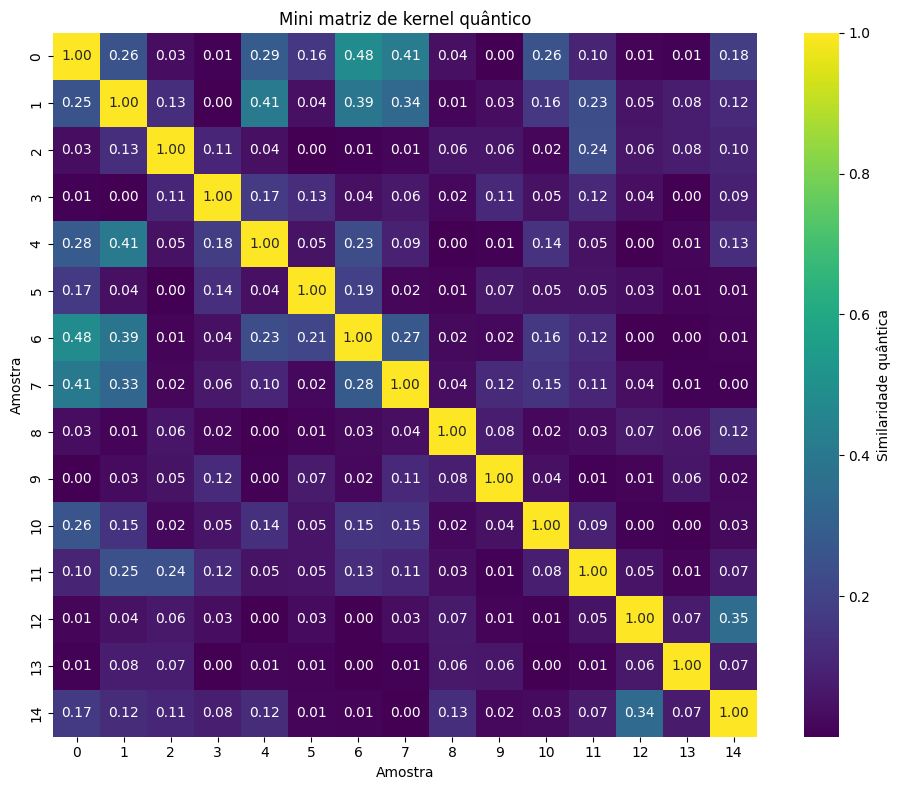

In [86]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    kernel_matrix,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    square=True,
    cbar_kws={"label": "Similaridade quântica"}
)

plt.title("Mini matriz de kernel quântico")
plt.xlabel("Amostra")
plt.ylabel("Amostra")

plt.tight_layout()
plt.show()

### Análise da visualização da mini matriz de kernel quântico

A visualização da mini matriz de kernel quântico mostra as similaridades calculadas entre pares de amostras do espaço latente.

A diagonal principal apresenta valores iguais a 1, o que é esperado, pois cada amostra comparada com ela mesma possui similaridade máxima.

Fora da diagonal, os valores variam bastante. Alguns pares apresentam similaridade mais alta, enquanto outros possuem valores próximos de zero. Isso indica que o kernel quântico conseguiu representar diferenças entre as amostras, separando pares mais parecidos de pares menos parecidos.

Essa variação é importante para Machine Learning, porque modelos baseados em kernel dependem justamente dessas medidas de similaridade para tentar separar classes. Uma matriz com valores muito semelhantes entre si teria pouca utilidade para classificação. Neste caso, a matriz apresenta estrutura suficiente para ser interpretada como uma representação útil do relacionamento entre as amostras.

### Treinamento de SVM com kernel quântico pré-computado

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

labels = kernel_labels.to_numpy()
indices = np.arange(len(labels))

train_indices, test_indices = train_test_split(
    indices,
    test_size=0.4,
    random_state=42,
    stratify=labels
)

K_train = kernel_matrix[np.ix_(train_indices, train_indices)]
K_test = kernel_matrix[np.ix_(test_indices, train_indices)]

y_train_kernel = labels[train_indices]
y_test_kernel = labels[test_indices]

svm_quantum_kernel_model = SVC(
    kernel="precomputed",
    class_weight="balanced",
    random_state=42
)

svm_quantum_kernel_model.fit(K_train, y_train_kernel)

y_pred_quantum_kernel = svm_quantum_kernel_model.predict(K_test)

accuracy_quantum_kernel_svm = accuracy_score(
    y_test_kernel,
    y_pred_quantum_kernel
)

print("Accuracy:", round(accuracy_quantum_kernel_svm, 4))
print("\nClassification Report:")
print(classification_report(y_test_kernel, y_pred_quantum_kernel))

Accuracy: 0.6667

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.67      1.00      0.80         2
           2       0.67      1.00      0.80         2

    accuracy                           0.67         6
   macro avg       0.44      0.67      0.53         6
weighted avg       0.44      0.67      0.53         6



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

### Análise do SVM com kernel quântico pré-computado

O SVM foi treinado usando a mini matriz de kernel quântico como entrada pré-computada. Nesse caso, o modelo não calculou um kernel clássico automaticamente; ele usou diretamente as similaridades geradas pelos circuitos quânticos.

O modelo obteve accuracy de 66,67% no conjunto de teste. Porém, esse resultado precisa ser analisado com cautela, porque o teste possui apenas 6 amostras, sendo 2 exemplos por classe. Com uma base tão pequena, poucos acertos ou erros já alteram bastante as métricas.

A classe `0`, correspondente a `CANDIDATE`, teve desempenho 0. Isso significa que o modelo não previu nenhuma amostra como `CANDIDATE` nesse pequeno conjunto de teste. Por isso, o Scikit-learn exibiu o aviso `UndefinedMetricWarning`, indicando que a precision não pôde ser calculada para essa classe.

As classes `1` (`CONFIRMED`) e `2` (`FALSE POSITIVE`) tiveram melhor desempenho, com recall de 1.00. Isso indica que as amostras dessas classes presentes no teste foram identificadas corretamente, mas o modelo ainda não conseguiu equilibrar bem as três classes.

Mesmo com essa limitação, esta etapa é importante porque conecta diretamente o circuito quântico ao Machine Learning. A matriz de similaridade gerada pelos circuitos foi usada como entrada real para um classificador SVM com `kernel="precomputed"`.

Assim, o experimento deixa de ser apenas a execução de circuitos isolados e passa a demonstrar um fluxo completo: Autoencoder, espaço latente, kernel quântico, matriz de similaridade e classificação com SVM.

### Matriz de confusão do SVM com kernel quântico

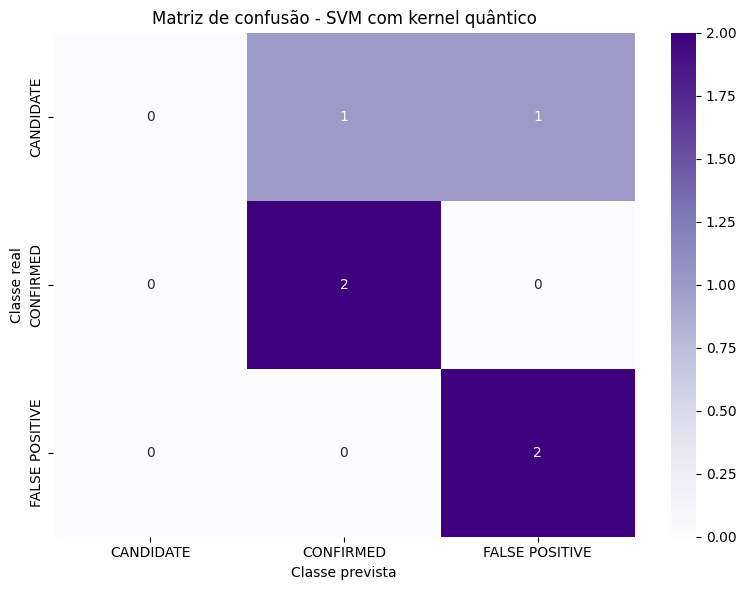

In [88]:
class_names = [
    "CANDIDATE",
    "CONFIRMED",
    "FALSE POSITIVE"
]

conf_matrix_quantum_svm = confusion_matrix(
    y_test_kernel,
    y_pred_quantum_kernel
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    conf_matrix_quantum_svm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Matriz de confusão - SVM com kernel quântico")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")

plt.tight_layout()
plt.show()

### Análise da matriz de confusão do SVM com kernel quântico

A matriz de confusão mostra que o SVM com kernel quântico acertou as duas amostras da classe `CONFIRMED` e as duas amostras da classe `FALSE POSITIVE`.

A principal dificuldade ficou na classe `CANDIDATE`. As duas amostras reais dessa classe foram classificadas como `CONFIRMED` e `FALSE POSITIVE`, indicando que o modelo ainda não conseguiu separar bem candidatos nesse conjunto pequeno de teste.

Como o teste possui apenas 6 amostras, essa matriz deve ser interpretada como uma prova de conceito, e não como uma avaliação definitiva de desempenho.

### Análise final do notebook de Quantum Machine Learning

Neste notebook, foi construída uma etapa experimental de `Quantum Machine Learning` conectada ao restante do projeto.

A proposta foi usar as representações latentes geradas pelo Autoencoder como entrada para circuitos quânticos. Essa escolha faz sentido porque o Autoencoder reduziu as 15 variáveis originais para 4 variáveis latentes, tornando o problema mais viável para um experimento com Qiskit.

A parte quântica foi baseada na ideia de `Quantum Kernel`. Em Machine Learning, métodos baseados em kernel usam medidas de similaridade entre amostras para ajudar na separação das classes. No caso do Quantum Kernel, essa similaridade é calculada depois que os dados são codificados em circuitos quânticos.

Primeiro, duas amostras foram comparadas por meio de um circuito de overlap. A execução em simulador local retornou uma probabilidade de 0,2559 para o estado `0000`, enquanto a execução no hardware real `ibm_marrakesh` retornou 0,2080. Essa diferença é esperada, pois o simulador representa um ambiente ideal, enquanto o hardware real sofre influência de ruídos e limitações físicas.

Depois, foi criada uma mini matriz de kernel quântico com 15 amostras balanceadas. Essa matriz representa a similaridade entre pares de amostras no espaço quântico e foi usada em um SVM com `kernel="precomputed"`. Assim, o experimento deixou de ser apenas uma execução de circuito e passou a se conectar diretamente a um fluxo de Machine Learning.

O resultado do SVM com kernel quântico deve ser visto como uma prova de conceito, pois foi treinado e testado com poucas amostras. Mesmo assim, ele mostra um caminho técnico importante: `Autoencoder → espaço latente → circuito quântico → matriz de kernel → classificação`.

Para o futuro, essa abordagem poderia ser expandida com mais amostras, melhor seleção de features latentes, diferentes feature maps e técnicas de mitigação de erro em hardware real. Em aplicações espaciais, esse tipo de pesquisa pode contribuir para novas formas de analisar grandes volumes de dados astronômicos, como sinais de trânsito planetário, eventos raros e candidatos a exoplanetas que exigem priorização para investigação científica.